# 04 时间维度分析

**要回答的问题**：延迟率有没有季节性？月末是不是更忙？早晚高峰是不是更容易延迟？

**为什么值得单独做**：很多业务现象本质上就是时间现象。而且
`Timestamp` 是源项目**唯一完全没有涉及的维度**。

**前置工作**：`Timestamp` 读进来是字符串，必须先转成 `datetime` 才能按时间分组。

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 从 notebooks/ 启动，因此父目录就是项目根目录
DATA = Path.cwd().parent / 'data' / 'raw' / 'smart_logistics_dataset.csv'
df = pd.read_csv(DATA, keep_default_na=False, na_values=[''])
total_shipments = len(df)

print(f'{total_shipments} 行 × {df.shape[1]} 列')


1000 行 × 16 列


In [2]:
# =====================================================================
# 时间维度分析 —— 源项目完全没有涉及的维度
#
# 为什么值得做：很多业务现象本质上是时间现象。延迟率有没有季节性？
#              月末是不是更忙？早晚高峰是不是更堵？
# 前置工作：Timestamp 读进来是字符串，必须先转成 datetime 才能按时间分组。
# =====================================================================

print('转换前 dtype：', df['Timestamp'].dtype)

df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print('转换后 dtype：', df['Timestamp'].dtype)

print()
print('时间范围：', df['Timestamp'].min(), '~', df['Timestamp'].max())
print('唯一时间戳：', df['Timestamp'].nunique(), '/', len(df))

dup = len(df) - df['Timestamp'].nunique()
print(f'重复时间戳：{dup} 行')

overall = df['Logistics_Delay'].astype(int).mean()
print()
print(f'总体延迟率（后续各图都要与它比较）：{overall:.2%}')


转换前 dtype： str
转换后 dtype： datetime64[us]

时间范围： 2024-01-01 11:37:00 ~ 2024-12-30 20:21:00
唯一时间戳： 1000 / 1000
重复时间戳：0 行

总体延迟率（后续各图都要与它比较）：56.60%


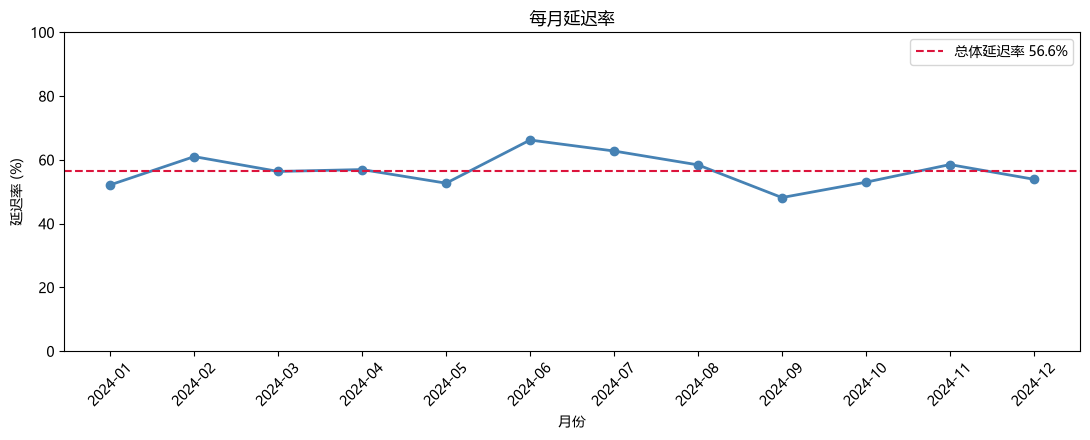

           delay_rate   n
Timestamp                
2024-01         52.17  92
2024-02         61.04  77
2024-03         56.38  94
2024-04         56.98  86
2024-05         52.70  74
2024-06         66.23  77
2024-07         62.79  86
2024-08         58.44  77
2024-09         48.19  83
2024-10         53.01  83
2024-11         58.54  82
2024-12         53.93  89

最低 48.2%  最高 66.2%  极差 18.0 个百分点
月度 × 延迟 卡方检验：chi2=9.3792  dof=11  p=0.5869  -> 无显著差异


In [3]:
# --- 1. 月度延迟率：是否存在季节性？ ---

monthly = (df.groupby(df['Timestamp'].dt.to_period('M'))['Logistics_Delay']
             .agg(['mean', 'size']))
monthly.index = monthly.index.astype(str)
monthly.columns = ['delay_rate', 'n']

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly.index, monthly['delay_rate'] * 100,
        marker='o', color='steelblue', linewidth=2)
ax.axhline(overall * 100, color='crimson', linestyle='--',
           label=f'总体延迟率 {overall:.1%}')
ax.set_title('每月延迟率')
ax.set_xlabel('月份')
ax.set_ylabel('延迟率 (%)')
ax.set_ylim(0, 100)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(monthly.assign(delay_rate=lambda d: (d['delay_rate'] * 100).round(2)).to_string())
print()
print(f"最低 {monthly['delay_rate'].min():.1%}  最高 {monthly['delay_rate'].max():.1%}  "
      f"极差 {100 * (monthly['delay_rate'].max() - monthly['delay_rate'].min()):.1f} 个百分点")

ct_month = pd.crosstab(df['Timestamp'].dt.month, df['Logistics_Delay'])
chi2_m, p_m, dof_m, _ = chi2_contingency(ct_month.values)
print(f'月度 × 延迟 卡方检验：chi2={chi2_m:.4f}  dof={dof_m}  p={p_m:.4f}'
      f'  -> {"显著" if p_m < 0.05 else "无显著差异"}')


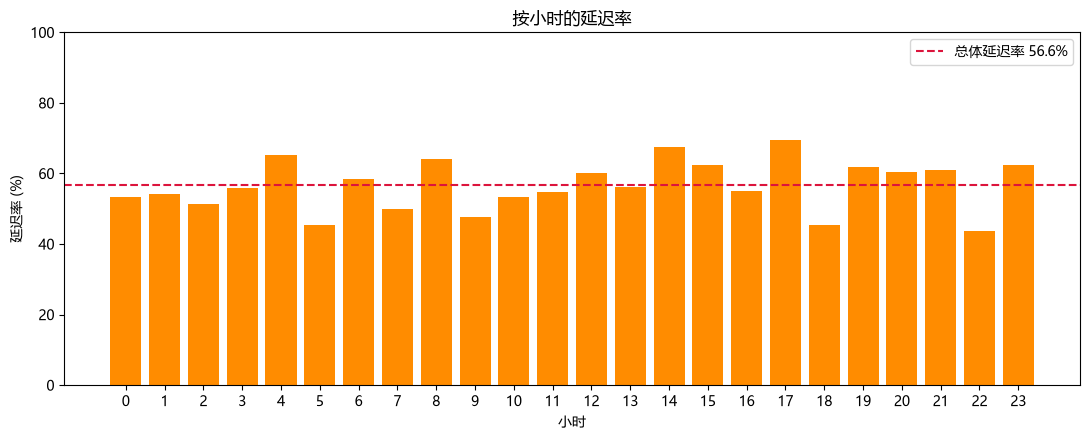

           delay_rate   n
Timestamp                
0               53.19  47
1               54.29  35
2               51.28  39
3               55.81  43
4               65.12  43
5               45.45  33
6               58.33  36
7               50.00  34
8               64.00  50
9               47.73  44
10              53.45  58
11              54.76  42
12              60.00  55
13              56.25  32
14              67.44  43
15              62.50  40
16              55.00  40
17              69.44  36
18              45.45  44
19              61.76  34
20              60.53  38
21              60.87  46
22              43.75  48
23              62.50  40

最低 43.8%  最高 69.4%
小时 × 延迟 卡方检验：chi2=19.4728  dof=23  p=0.6735  -> 无显著差异


In [4]:
# --- 2. 小时延迟率：是否存在高峰效应？ ---

hourly = (df.groupby(df['Timestamp'].dt.hour)['Logistics_Delay']
            .agg(['mean', 'size']))
hourly.columns = ['delay_rate', 'n']

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(hourly.index, hourly['delay_rate'] * 100, color='darkorange')
ax.axhline(overall * 100, color='crimson', linestyle='--',
           label=f'总体延迟率 {overall:.1%}')
ax.set_title('按小时的延迟率')
ax.set_xlabel('小时')
ax.set_ylabel('延迟率 (%)')
ax.set_ylim(0, 100)
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

print(hourly.assign(delay_rate=lambda d: (d['delay_rate'] * 100).round(2)).to_string())
print()
print(f"最低 {hourly['delay_rate'].min():.1%}  最高 {hourly['delay_rate'].max():.1%}")

ct_hour = pd.crosstab(df['Timestamp'].dt.hour, df['Logistics_Delay'])
chi2_h, p_h, dof_h, _ = chi2_contingency(ct_hour.values)
print(f'小时 × 延迟 卡方检验：chi2={chi2_h:.4f}  dof={dof_h}  p={p_h:.4f}'
      f'  -> {"显著" if p_h < 0.05 else "无显著差异"}')


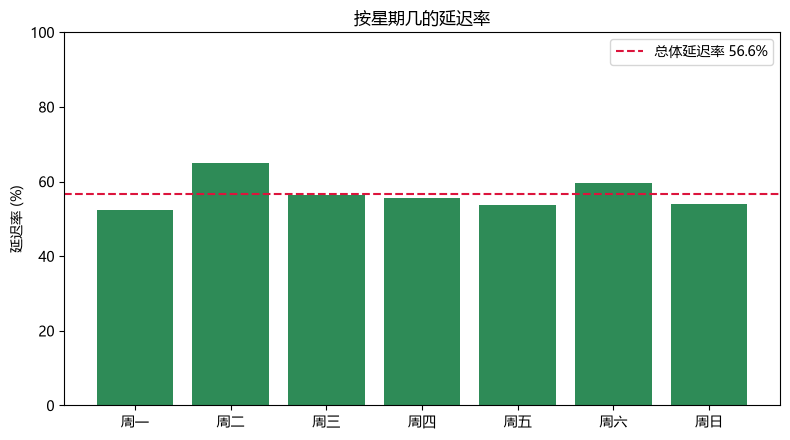

    delay_rate    n
周一       52.29  153
周二       65.00  140
周三       56.33  158
周四       55.56  135
周五       53.74  147
周六       59.71  139
周日       53.91  128

最低 52.3%  最高 65.0%
星期 × 延迟 卡方检验：chi2=6.6596  dof=6  p=0.3535  -> 无显著差异


In [5]:
# --- 3. 星期几延迟率 ---

names = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
weekday = (df.groupby(df['Timestamp'].dt.dayofweek)['Logistics_Delay']
             .agg(['mean', 'size']))
weekday.columns = ['delay_rate', 'n']
weekday.index = [names[i] for i in weekday.index]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(weekday.index, weekday['delay_rate'] * 100, color='seagreen')
ax.axhline(overall * 100, color='crimson', linestyle='--',
           label=f'总体延迟率 {overall:.1%}')
ax.set_title('按星期几的延迟率')
ax.set_ylabel('延迟率 (%)')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

print(weekday.assign(delay_rate=lambda d: (d['delay_rate'] * 100).round(2)).to_string())
print()
print(f"最低 {weekday['delay_rate'].min():.1%}  最高 {weekday['delay_rate'].max():.1%}")

ct_wd = pd.crosstab(df['Timestamp'].dt.dayofweek, df['Logistics_Delay'])
chi2_w, p_w, dof_w, _ = chi2_contingency(ct_wd.values)
print(f'星期 × 延迟 卡方检验：chi2={chi2_w:.4f}  dof={dof_w}  p={p_w:.4f}'
      f'  -> {"显著" if p_w < 0.05 else "无显著差异"}')


In [6]:
# =====================================================================
# 时间维度小结
# =====================================================================

summary = pd.DataFrame([
    {'维度': '月度（12 组）', '极差(百分点)':
        100 * (monthly['delay_rate'].max() - monthly['delay_rate'].min()),
     'p 值': p_m},
    {'维度': '小时（24 组）', '极差(百分点)':
        100 * (hourly['delay_rate'].max() - hourly['delay_rate'].min()),
     'p 值': p_h},
    {'维度': '星期（7 组）', '极差(百分点)':
        100 * (weekday['delay_rate'].max() - weekday['delay_rate'].min()),
     'p 值': p_w},
])
summary['极差(百分点)'] = summary['极差(百分点)'].round(2)
summary['p 值'] = summary['p 值'].round(4)
summary['是否显著(p<0.05)'] = summary['p 值'] < 0.05
print(summary.to_string(index=False))

print()
print(f'总体延迟率 {overall:.2%}，三个维度的各分组都围绕它上下波动，')
print('没有任何一个维度呈现出单调趋势或明显的周期性。')

sig = summary['是否显著(p<0.05)'].sum()
if sig == 0:
    print()
    print('结论：时间维度同样不存在可利用的规律，')
    print('      这是"这份数据是合成的"的第四条独立证据。')
else:
    print()
    print(f'注意：有 {int(sig)} 个维度达到统计显著。'
          '本表共做了 3 次检验，按邦弗朗尼校正门槛应为 0.05/3≈0.017，'
          '请据此判断是否属于多重比较造成的假阳性。')


      维度  极差(百分点)    p 值  是否显著(p<0.05)
月度（12 组）    18.04 0.5869         False
小时（24 组）    25.69 0.6735         False
 星期（7 组）    12.71 0.3535         False

总体延迟率 56.60%，三个维度的各分组都围绕它上下波动，
没有任何一个维度呈现出单调趋势或明显的周期性。

结论：时间维度同样不存在可利用的规律，
      这是"这份数据是合成的"的第四条独立证据。


## 小结

三个时间维度各自分组后的延迟率都围绕总体延迟率波动，没有一个呈现单调趋势或周期性。
**"没有发现规律"本身就是一个结论**——它是"数据是合成的"的第四条独立证据。